# Setup


In [184]:
### --- Dev imports STARTS --- ###
from dotenv import load_dotenv
load_dotenv()
from tavily import TavilyClient
tavily_client = TavilyClient()
import time
from datetime import timedelta
### --- Dev imports ENDS --- ###

### --- Langchain speicifics STARTS --- ###
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from langchain.messages import AIMessage, SystemMessage, HumanMessage
from langchain.agents import create_agent
### --- Langchain speicifics ENDS --- ###

### --- Data preprocessing imports STARTS --- ###
import base64, io
from PIL import Image
### --- Data preprocessing imports ENDS --- ###


# What is **multimodal** destinated for?
To ensure a smooth and fast message transition/transmission of non-text data some transformations should be applied and consequently particular communication pathways should be used. 

## Image input
For the sake of demonstration one could use built-in jupyter specific widgets (aka `ipywidgets`) as a method to input an image into this environment. However, walking down such an avenue will consequently lead you in an environment holding limited options when comes about pipelining. Having this setback in mind I decided to provide instructions on rather common methods used in M.L. for image import and processign

### 1. Load and determine how rich the image is

In [130]:
# One "limited" way
from ipywidgets import FileUpload
uploader = file_uploader_button = FileUpload(accept=".webp", multiple=False)
from IPython.display import display
display(file_uploader_button)
from pprint import pprint

# One pipeline-frendly/flexible enough way
from matplotlib import pyplot as plot
import pandas as pd
import cv2
image_path:str = "../../datasets/p0hwppzn.jpg.webp"
binary_img = cv2.imread(image_path)
color_img = cv2.cvtColor(binary_img, cv2.COLOR_BGR2RGB)

FileUpload(value=(), accept='.webp', description='Upload')

()
[255]


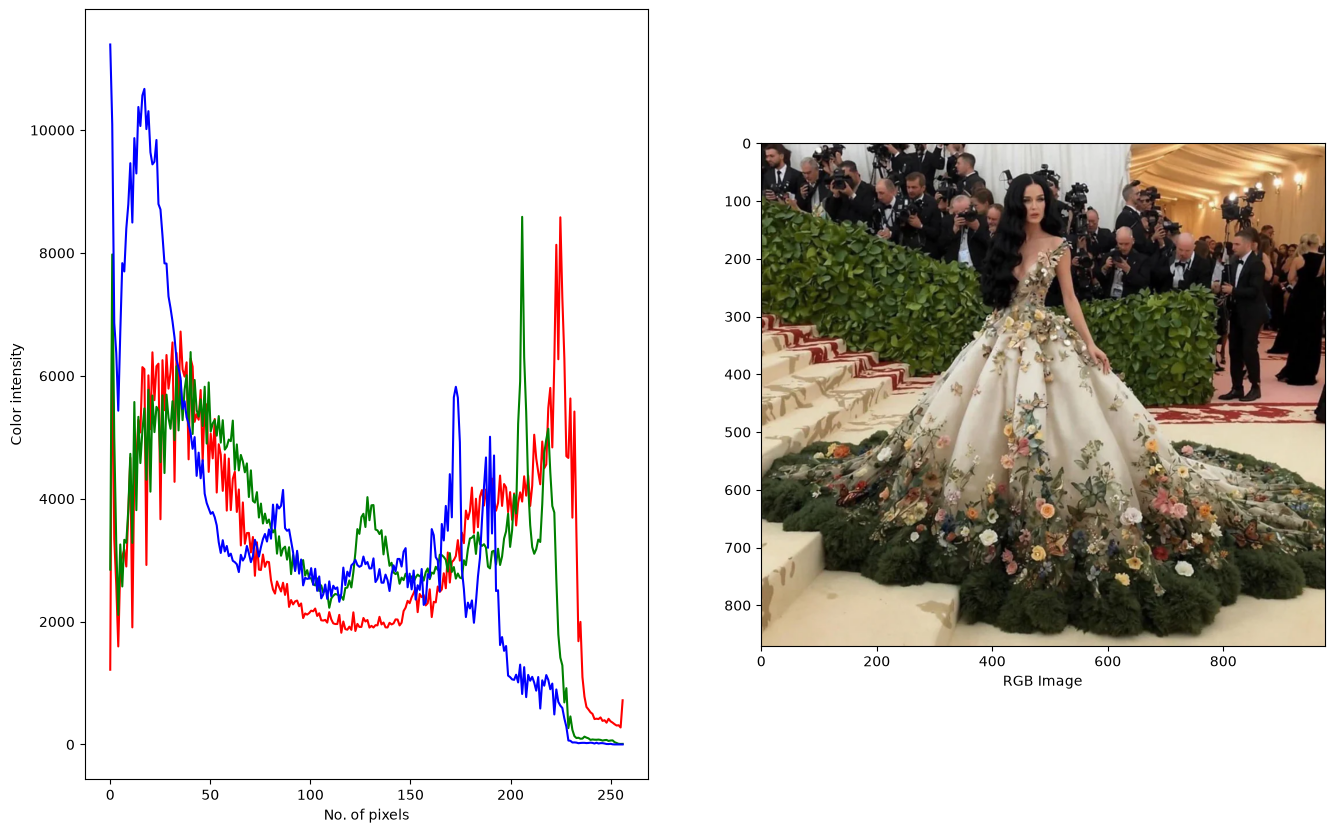

In [ ]:
# 1. Print information regarding previously imported image
pprint(uploader.value)
# 2. Determine the color intensities by iterating through image channels
color_scheme:list[str] = ['r', 'g', 'b']
print([color_img.max().__int__()])

def display_img_color_scheme(color_img):

    # 1. Check the image type to set the upper and lower boundaries
    if color_img.dtype.kind == 'f':
        bins = 256
        hist_range = [0.0, 1.0]
    else:
        # Fallback for standard 0-255 uint8 images
        bins = 256
        hist_range = [0.0, 256.0]

    fig, axes = plot.subplots(1,2, figsize=(16,10))
    for color in range(len(color_scheme)):
        # Explicitly pass float-compatible bin sizes and ranges
        hist = cv2.calcHist([color_img], [color], None, [bins], hist_range)
        
        # We construct an X-axis matching the exact range of our image (0.0 to 1.0)
        # to ensure the plot accurately reflects the new decimal scale!
        import numpy as np
        x_axis = np.linspace(hist_range[0], hist_range[1], bins)
        
        axes[0].plot(x_axis, hist, color=color_scheme[color])

    axes[0].set_xlabel("No. of pixels")
    axes[0].set_ylabel("Color intensity")
    axes[1].imshow(color_img)
    axes[1].set_xlabel("RGB Image")

display_img_color_scheme(color_img=color_img)

### 2. Apply adequate transformations to the image to ensure rapid data transmission 
Firstly, normalize the image such that its value do not vary outside a speciifc interval `minmax = (0,1)`

Secondly, convert to 8-bits base from 64 using `base64`

Before (np.uint8(0), np.uint8(255)) & After (np.float32(0.0), np.float32(1.0)) intervals
{'content': <memory at 0x00000242C4BCD300>,
 'last_modified': datetime.datetime(2026, 9, 21, 9, 59, 1, 56000, tzinfo=datetime.timezone.utc),
 'name': 'p0hwppzn.jpg.webp',
 'size': 119718,
 'type': 'image/webp'}


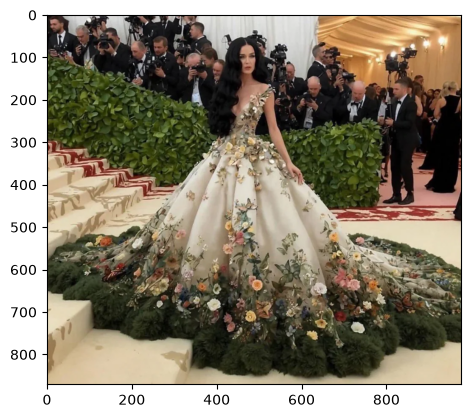

In [214]:
def img_norm(image):
    norm_image = cv2.normalize(src=image,dst=None,alpha=0.0, beta=1.0, norm_type=cv2.NORM_MINMAX,dtype=cv2.CV_32F)
    print(f"Before {image.min(), image.max()} & After {norm_image.min(), norm_image.max()} intervals")
    return norm_image
norm_img_colored = img_norm(color_img)
# display_img_color_scheme(color_img=norm_img_colored) 

# Get the first (and only) uploaded file dict
uploaded_file = uploader.value[0]
pprint(uploaded_file)
# This is a memoryview (analogus to saving the address at a bit memory level)
content_mv = uploaded_file["content"]
# Convert memoryview -> bytes
img_bytes = bytes(content_mv)  # or content_mv.tobytes()
# Now base64 encode
# Unormalised image whose base was converted to 64
img_b64 = base64.b64encode(img_bytes).decode("utf-8")

# Verify whether the encoding is faithfully representing the initial image
image_data = base64.b64decode(img_b64)
image = Image.open(io.BytesIO(image_data))
plot.imshow(image)

# Normalised image whose base was converted to 64
# 1. Binarize (Assuming normalized 0-1 range; thresholds at 0.5 to create 0 or 255)
bin_array = (norm_img_colored > 0.5).astype("uint8") * 255

# 2. Compress directly into a PNG file structure memory buffer
_, buffer = cv2.imencode(".png", bin_array)
# 3. Base64 encode the buffer bytes
norm_img_b64 = base64.b64encode(buffer).decode("utf-8")

### 3. Identify whether or not the responding time varies with the input type

In [ ]:
question = HumanMessage([
    {"type":"text", "text":"Could you describe to me this image"},
    {"type":"image","base64":img_b64, "mime_type":"image/webp"}
])

chat_model = init_chat_model(model="gemini-2.5-flash", model_provider="google_genai")
gemini_agent = create_agent(chat_model)
response = gemini_agent.invoke({"messages":question})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [179]:
pprint(response['messages'][-1])

AIMessage(content='This image captures Katy Perry on a red carpet, likely at a high-profile event like the Met Gala, wearing an incredibly elaborate and whimsical gown with a strong nature theme.\n\nHere\'s a detailed description:\n\n**The Central Figure (Katy Perry):**\nKaty Perry stands poised, looking directly forward with a serious, almost ethereal expression. Her long, dark, wavy hair is parted down the middle and cascades over her shoulders. She wears minimal visible jewelry, allowing the dress to be the focal point.\n\n**The Gown:**\nThe dress is a breathtaking ball gown with an expansive skirt and a very long train, creating the illusion of a living garden.\n*   **Bodice:** The fitted bodice is a light, off-white or ivory color, featuring an elegant V-neckline and off-the-shoulder straps. It\'s adorned with delicate three-dimensional embellishments, primarily light-colored butterflies and smaller flowers in shades of yellow, cream, and faint pink.\n*   **Skirt and Train:** As t

In [215]:
images = [img_b64,norm_img_b64]
durations:list = []
responses:list = []
for image in range(2):
    question = HumanMessage([
        {"type":"text", "text":"Could you describe to me this image"},
        {"type":"image","base64":images[image], "mime_type":"image/webp"}
    ])
     
    start_time = time.perf_counter()
    response = gemini_agent.invoke({"messages":question})
    duration = timedelta(minutes=time.perf_counter()-start_time)

    durations.append(duration)
    responses.append(response)

In [220]:
print(durations)
print(responses[0]['messages'][-1],"\n",responses[1]['messages'][-1])

[datetime.timedelta(seconds=625, microseconds=120560), datetime.timedelta(seconds=603, microseconds=398646)]
content="This image captures a wide shot of Katy Perry on a grand red carpet, likely at a high-profile event like the Met Gala, given the elaborate nature of her attire and the surrounding press.\n\n**Central Figure:**\nKaty Perry stands prominently in the center, looking directly towards the camera with a composed, almost serious expression. Her long, dark, wavy hair is parted down the middle and cascades over her shoulders.\n\n**The Dress:**\nShe is wearing an extraordinarily elaborate ball gown that is the focal point of the image.\n*   **Bodice:** The dress features an off-the-shoulder, deep V-neckline bodice in a light, possibly cream or ivory, fabric. It's adorned with delicate, light-colored butterfly appliques.\n*   **Skirt and Train:** The voluminous skirt flares out dramatically from her waist, extending into a very long and wide train that sprawls across the stairs an

## Audio input

In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write
import base64
import io
import time
from tqdm import tqdm

# Recording settings
duration = 5  # seconds
sample_rate = 44100

print("Recording...")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
# Progress bar for the duration
for _ in tqdm(range(duration * 10)):   # update 10× per second
    time.sleep(0.1)
sd.wait()
print("Done.")

# Write WAV to an in-memory buffer
buf = io.BytesIO()
write(buf, sample_rate, audio)
wav_bytes = buf.getvalue()

aud_b64 = base64.b64encode(wav_bytes).decode("utf-8")

In [ ]:
agent = create_agent(
    model='gpt-audio',
)

multimodal_question = HumanMessage(content=[
    {"type": "text", "text": "Tell me about this audio file"},
    {"type": "audio", "base64": aud_b64, "mime_type": "audio/wav"}
])

response = agent.invoke(
    {"messages": [multimodal_question]}
)

print(response['messages'][-1].content)